# Pathway analysis tutorial

In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cantera as ct
from IPython.display import Image, display

from pathwaylib.stiffsolver import stiff_solver
from pathwaylib.pathwayIO import reaction_info, write_csv
from pathwaylib.pathway import Pathway
from pathwaylib.visualize import createDiag

## Load data, which must contain Y, T and p

In [2]:
df = pd.read_csv("./data/line.csv")
df.head()

,x,H,H2,OH,HO2,H2O2,N2,O,O2,Al,...,OAlO,AlOH,Al2O3,Al2O3c,AlOAl,AlOAlO,AR,T,rho,p
0,0.000281,0.001802,0.002929,4.194405e-08,2.099475e-15,4.146678e-17,0.048193,2.889621e-08,3.252997e-12,0.808622,...,1.023955e-12,0.000011,4.256191e-20,4.354663e-20,0.033899,4.185344e-08,1.202669e-16,2823.127150,0.117348,101325
1,0.000283,0.001854,0.002986,4.838188e-08,2.467014e-15,4.873713e-17,0.049290,3.394376e-08,3.822428e-12,0.804354,...,1.203508e-12,0.000012,5.001853e-20,5.117663e-20,0.034655,4.403932e-08,1.229551e-16,2852.517564,0.116131,101325
2,0.000285,0.001909,0.003041,5.704300e-08,2.981768e-15,5.892163e-17,0.050412,4.085755e-08,4.620055e-12,0.800022,...,1.455019e-12,0.000012,6.046274e-20,6.186390e-20,0.035424,4.711893e-08,1.256927e-16,2881.062743,0.114976,101325
3,0.000288,0.001969,0.003095,6.819598e-08,3.672527e-15,7.259228e-17,0.051557,4.991629e-08,5.690584e-12,0.795627,...,1.792641e-12,0.000013,7.448047e-20,7.620819e-20,0.036206,5.128775e-08,1.284787e-16,2908.788216,0.113882,101325
4,0.000290,0.002033,0.003148,8.220661e-08,4.577199e-15,9.050393e-17,0.052725,6.152553e-08,7.093008e-12,0.791173,...,2.235106e-12,0.000013,9.284485e-20,9.500086e-20,0.036999,5.672129e-08,1.313117e-16,2935.718031,0.112825,101325


## An example

Running stiff solver on 43 points using 10 cores...


Stiff solver:   0%|          | 0/43 [00:00<?, ?it/s]/Users/zhouyuchen/Desktop/pathwaylib/pathwaylib/stiffsolver.py:70: UserWarning: NasaPoly2::validate: 
For species Al2O3(L), discontinuity in cp/R detected at Tmid = 2327
	Value computed using low-temperature polynomial:  16.711360851932312
	Value computed using high-temperature polynomial: 19.592255

  gas = ct.Solution(mechanism, verbose=0)
/Users/zhouyuchen/Desktop/pathwaylib/pathwaylib/stiffsolver.py:70: UserWarning: NasaPoly2::validate: 
For species Al2O3(L), discontinuity in s/R detected at Tmid = 2327
	Value computed using low-temperature polynomial:  35.10933824372687
	Value computed using high-temperature polynomial: 41.02352436488516

  gas = ct.Solution(mechanism, verbose=0)
/Users/zhouyuchen/Desktop/pathwaylib/pathwaylib/stiffsolver.py:70: UserWarning: NasaPoly2::validate: 
For species Al2O3(L), discontinuity in cp/R detected at Tmid = 2327
	Value computed using low-temperature polynomial:  16.711360851932312
	Value compute

Maximum HRR:2.110391e+11 W/m³
Maximum flux:7.146251e+02 kmol/m³/s


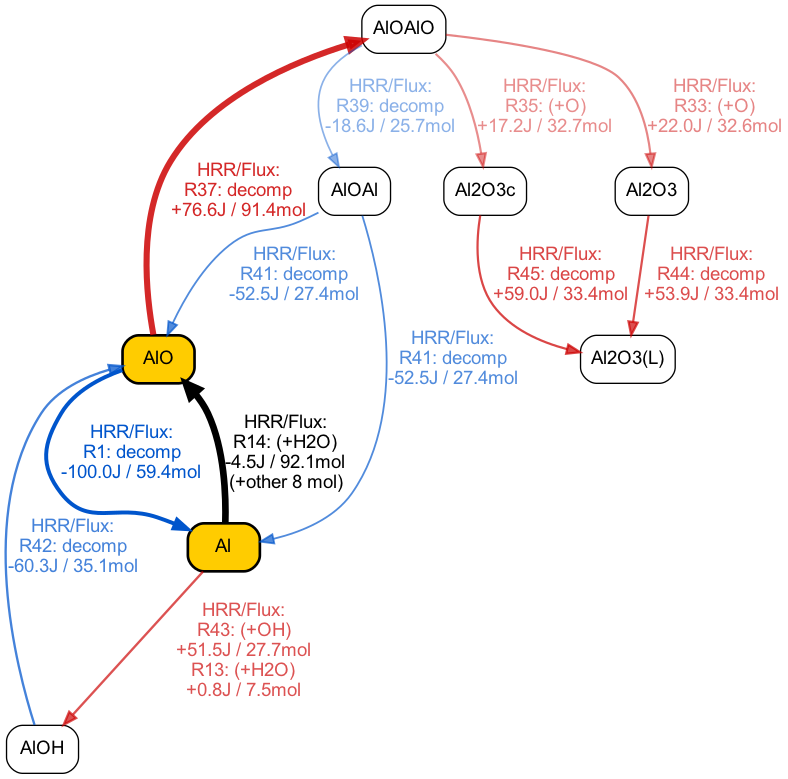

In [3]:

#===================== Settngs =======================#
# flow time of your simulation timestep
integrateTime = 1.4e-7 

# mechanism
mechanism = "./Glorian.yaml"

# species to trace
species_to_trace = 'Al'

# filters, can be many entries, e.g. filter = {"x": (lrange, yrange), "y": (lrange, yrange), ...}
# note x and y should be the same as the column names in the CSV file, e.g. Al, AlO, T, etc.
r = R_REF = 0.000275
lrange, yrange = 2.5 * r, 3.0 * r
filter = {"x": (lrange, yrange),}


# highlight species
highlightSpecies = ['Al', 'AlO', 'AlH']

## threshold for visualization, all default to 0.1
# species A ----(edge) strength 1.00-----> species B
#                                             ^
#                                             |
#                                             |
#                                           (edge) strength 0.05 (R1 0.0049, R2 0.0001)
#                                             |
#                                           species C 
# for flux weaker than 10% of the maximum flux, ignore the edge (edge C-B will be ignore)
edgeThres     = 0.1 
# for the same edge, ignore the least important 10% reactions (R2 will be ignored)
entryThres    = 0.1 
# for two edges sharing a same end, ignore the edge with smaller flux 
# if the the strength of one is weaker than 10% of the other 
# in this case, ignore edge C-B since 0.05 is weaker than 10% of 1.00
neighborThres = 0.1 

# savename
savename = "pathway"


#===================== Settngs =======================#

# equation_map = {f"R{i+1}": gas.reactions()[i].equation for i in range(gas.n_reactions)} 

# Pathway flux CSV + per-edge HRR dict
write_csv(
    mechanism       = mechanism,
    species_to_trace= species_to_trace,
    dataframe       = df,
    filter_dict = filter,
    deltaT = integrateTime,   #
    outputfile      = f'./results/csvs/{savename}.csv',
)
p1 = Pathway()
p1.load_csv(f'./results/csvs/{savename}.csv')

dot_flux = createDiag(
    p1,
    edgeThres        = edgeThres,
    entryThres       = entryThres,
    neighborThres    = neighborThres,
    highlightSpecies = highlightSpecies,
)
dot_flux.graph_attr['dpi'] = '500'
dot_flux.render(f'./results/figs/{savename}', format='png', cleanup=True)
display(Image(f'./results/figs/{savename}.png'))